# Step 3: Deep Dive Analysis

## Headline Goal
Understand exactly where within Single Game the decline is concentrated (which days, which months, day vs. night games), rule out data/scheduling that could be masking or exaggerating the real signal, and size the actual ticket/revenue opportunity available if weekday and Sunday demand were addressed.

1. **Single Game (Weekdays & Sunday)** - the dominant driver, gets the most depth
2. Full Season (price/attendance relationship) - second-largest
3. Partial Season (what's working/what can we learn) - highest-leverage lever


### - Establish Visualization Standards

In [1]:
# ============================================================
# Imports & Visualization Standards
# ============================================================
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# Standard color palette (order: Blue, Red, Teal, Yellow)
PALETTE = ['#0000a2', '#bc272d', '#50ad9f', '#e9c716']

# Standard figure size for all charts
FIGSIZE = (22, 8.5)

# Axis formatters
def thousands_formatter(x, pos):
    return f'{x/1000:,.0f}K'

def millions_formatter(x, pos):
    return f'${x/1_000_000:,.1f}M'

# Standard label styling
TITLE_STYLE = {'fontsize': 18, 'fontweight': 'bold'}
LABEL_STYLE = {'fontsize': 16, 'fontweight': 'bold'}

# Shared constants used across multiple analysis cells
YEARS = [2021, 2022, 2023]
YEAR_COLORS = dict(zip(YEARS, PALETTE))
DOW_ORDER = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
MONTH_ORDER = ['April', 'May', 'June', 'July', 'August', 'September']
DAYNIGHT_ORDER = ['Day Game', 'Night Game']
BAR_WIDTH = 0.25

### - Load in Data

In [2]:
full = pd.read_csv('../step_01_clean_data/clean_data.csv', parse_dates=['Game Date'])

print(f"Loaded: {full.shape[0]} rows, {full.shape[1]} columns")
full.head()

Loaded: 243 rows, 26 columns


,Home Game #,Game Date,Year,Month,Day of Week,Weekend / Weekday,Game Time,Day/Night,Full Season Tickets (#),Full Season Revenue ($),...,Group Avg Price ($),Single Game Tickets (#),Single Game Revenue ($),Single Game Avg Price ($),No-Show Rate,Total Tickets (#),Actual Attendance (#),Total Revenue ($),Average Ticket Price ($),Is First Month
0,1,2021-04-01,2021,April,Thursday,Weekday,13:10:00,Day Game,9361,417794.04,...,46.83,16916,1013906.60,59.94,0.1420,36688,31478,1870492.51,50.98,True
1,2,2021-04-02,2021,April,Friday,Weekend,19:10:00,Night Game,9374,415278.62,...,25.93,9023,272800.32,30.23,0.1752,24520,20224,852818.98,34.78,True
2,3,2021-04-03,2021,April,Saturday,Weekend,18:10:00,Night Game,9398,414149.54,...,30.51,10411,373733.78,35.90,0.1643,28927,24174,1057199.15,36.55,True
3,4,2021-04-04,2021,April,Sunday,Weekend,13:10:00,Day Game,9374,415431.58,...,30.16,12149,411154.96,33.84,0.1609,28561,23966,1057229.43,37.02,True
4,5,2021-04-09,2021,April,Friday,Weekend,19:10:00,Night Game,9376,416211.65,...,30.28,10282,408009.37,39.68,0.1570,29910,25214,1141873.37,38.18,True


# Single Game Ticket Decline — Deep Dive
### - Diagnosing where and when the decline is concentrated (day of week, day/night, month)

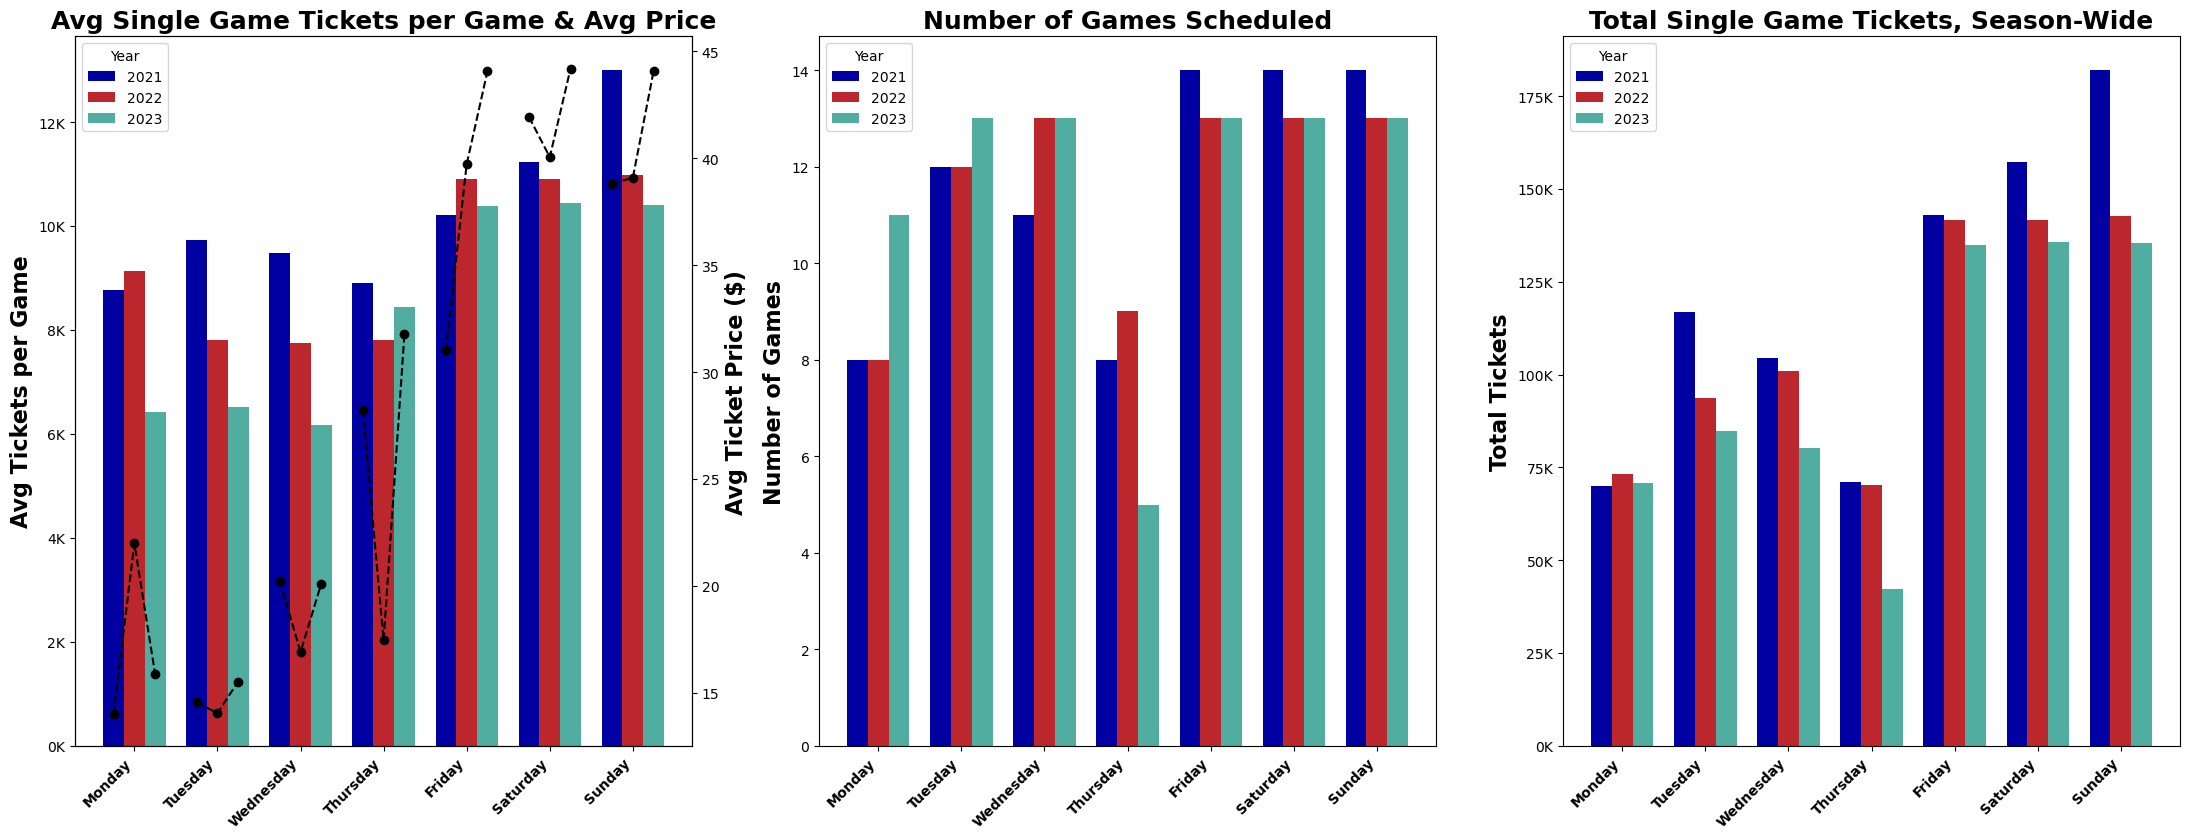

In [3]:
ticket_pivot = full.groupby(['Year', 'Day of Week'])['Single Game Tickets (#)'].mean().unstack().reindex(columns=DOW_ORDER)
price_pivot = full.groupby(['Year', 'Day of Week'])['Single Game Avg Price ($)'].mean().unstack().reindex(columns=DOW_ORDER)
game_counts = full.groupby(['Year', 'Day of Week']).size().unstack().reindex(columns=DOW_ORDER)
total_ticket_pivot = full.groupby(['Year', 'Day of Week'])['Single Game Tickets (#)'].sum().unstack().reindex(columns=DOW_ORDER)

fig, axes = plt.subplots(1, 3, figsize=FIGSIZE)

# LEFT: Avg tickets per game & price
ax = axes[0]
x = range(len(DOW_ORDER))
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    ax.bar([xi + i * BAR_WIDTH for xi in x], ticket_pivot.loc[year], width=BAR_WIDTH, label=str(year), color=color)
ax.set_title('Avg Single Game Tickets per Game & Avg Price', **TITLE_STYLE)
ax.set_xticks([xi + BAR_WIDTH for xi in x])
ax.set_xticklabels(DOW_ORDER, rotation=45, ha='right', fontweight='bold')
ax.set_ylabel('Avg Tickets per Game', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.legend(title='Year', loc='upper left')

ax_price = ax.twinx()
for xi in x:
    x_points = [xi + i * BAR_WIDTH for i in range(len(YEARS))]
    y_points = [price_pivot.loc[year].iloc[xi] for year in YEARS]
    ax_price.plot(x_points, y_points, color='black', marker='o', linewidth=1.5, linestyle='dashed')
ax_price.set_ylabel('Avg Ticket Price ($)', **LABEL_STYLE)

# MIDDLE: Number of games scheduled
ax_games = axes[1]
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    ax_games.bar([xi + i * BAR_WIDTH for xi in x], game_counts.loc[year], width=BAR_WIDTH, label=str(year), color=color)
ax_games.set_title('Number of Games Scheduled', **TITLE_STYLE)
ax_games.set_xticks([xi + BAR_WIDTH for xi in x])
ax_games.set_xticklabels(DOW_ORDER, rotation=45, ha='right', fontweight='bold')
ax_games.set_ylabel('Number of Games', **LABEL_STYLE)
ax_games.legend(title='Year', loc='upper left')

# RIGHT: Total tickets (avg x games scheduled, combined)
ax_total = axes[2]
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    ax_total.bar([xi + i * BAR_WIDTH for xi in x], total_ticket_pivot.loc[year], width=BAR_WIDTH, label=str(year), color=color)
ax_total.set_title('Total Single Game Tickets, Season-Wide', **TITLE_STYLE)
ax_total.set_xticks([xi + BAR_WIDTH for xi in x])
ax_total.set_xticklabels(DOW_ORDER, rotation=45, ha='right', fontweight='bold')
ax_total.set_ylabel('Total Tickets', **LABEL_STYLE)
ax_total.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax_total.legend(title='Year', loc='upper left')

plt.tight_layout()
plt.show()

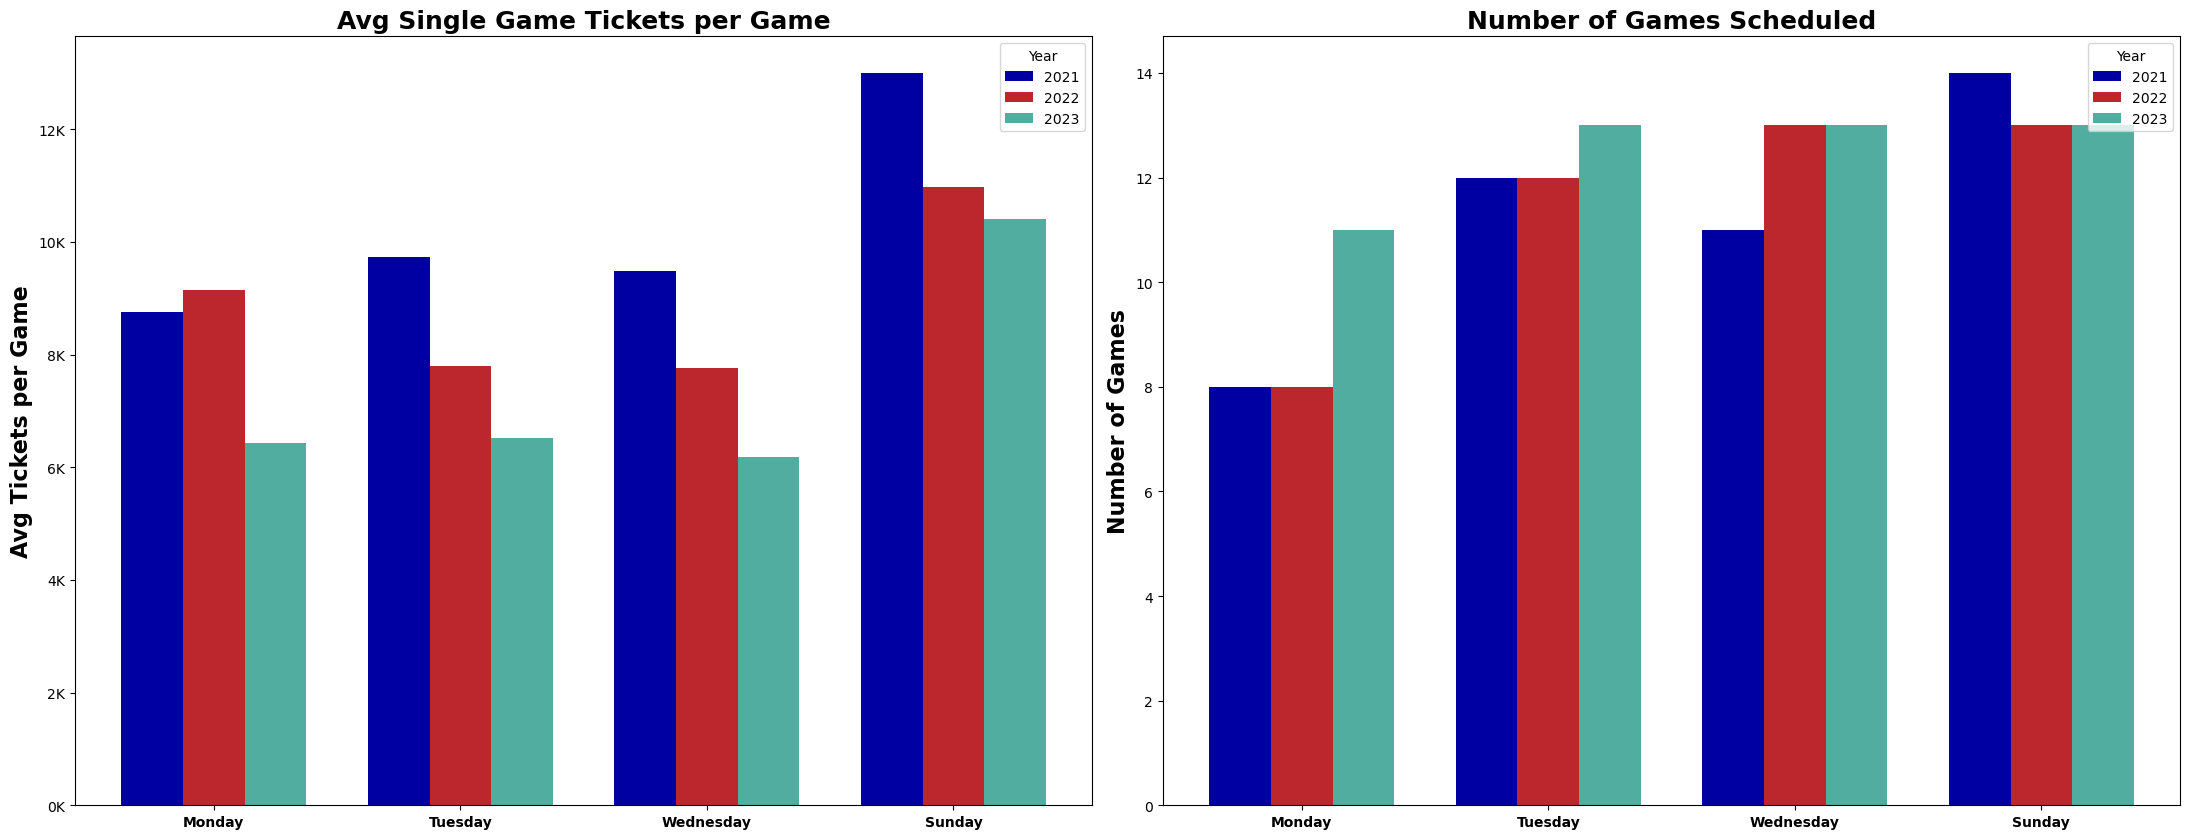

In [4]:
mtws_order = ['Monday', 'Tuesday', 'Wednesday', 'Sunday']
ticket_pivot_mtws = full.groupby(['Year', 'Day of Week'])['Single Game Tickets (#)'].mean().unstack().reindex(columns=mtws_order)
game_counts_mtws = full.groupby(['Year', 'Day of Week']).size().unstack().reindex(columns=mtws_order)

fig, axes = plt.subplots(1, 2, figsize=FIGSIZE)
xi_range = range(len(mtws_order))

# LEFT: Avg tickets per game, YoY
ax = axes[0]
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    ax.bar([xi + i * BAR_WIDTH for xi in xi_range], ticket_pivot_mtws.loc[year], width=BAR_WIDTH, label=str(year), color=color)
ax.set_title('Avg Single Game Tickets per Game', **TITLE_STYLE)
ax.set_xticks([xi + BAR_WIDTH for xi in xi_range])
ax.set_xticklabels(mtws_order, fontweight='bold')
ax.set_ylabel('Avg Tickets per Game', **LABEL_STYLE)
ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
ax.legend(title='Year', loc='upper right')

# RIGHT: Number of games scheduled, YoY
ax2 = axes[1]
for i, (year, color) in enumerate(YEAR_COLORS.items()):
    ax2.bar([xi + i * BAR_WIDTH for xi in xi_range], game_counts_mtws.loc[year], width=BAR_WIDTH, label=str(year), color=color)
ax2.set_title('Number of Games Scheduled', **TITLE_STYLE)
ax2.set_xticks([xi + BAR_WIDTH for xi in xi_range])
ax2.set_xticklabels(mtws_order, fontweight='bold')
ax2.set_ylabel('Number of Games', **LABEL_STYLE)
ax2.legend(title='Year', loc='upper right')

plt.tight_layout()
plt.show()

**Key Findings:**
- Monday (+3 games), Tuesday (+1 game), and Wednesday (+2 games). The three worst-performing days all had games **ADDED** to the schedule from 2021 to 2023, while Friday/Saturday/Sunday (the more resilient days) each had a game **REMOVED**. 
- Thursday (-3 games) is the one exception. This is despite relatively stable demand (-5.1%)
- Price again shows no consistent relationship with ticket trends across any day which confirms the pattern we've seen throughout this analysis

**Additional Notes:**
- Not sure if it was Acme or the League that does the scheduling, but games were added to its three worst days and cut games from its best

# Looking Deeper at each day of the week

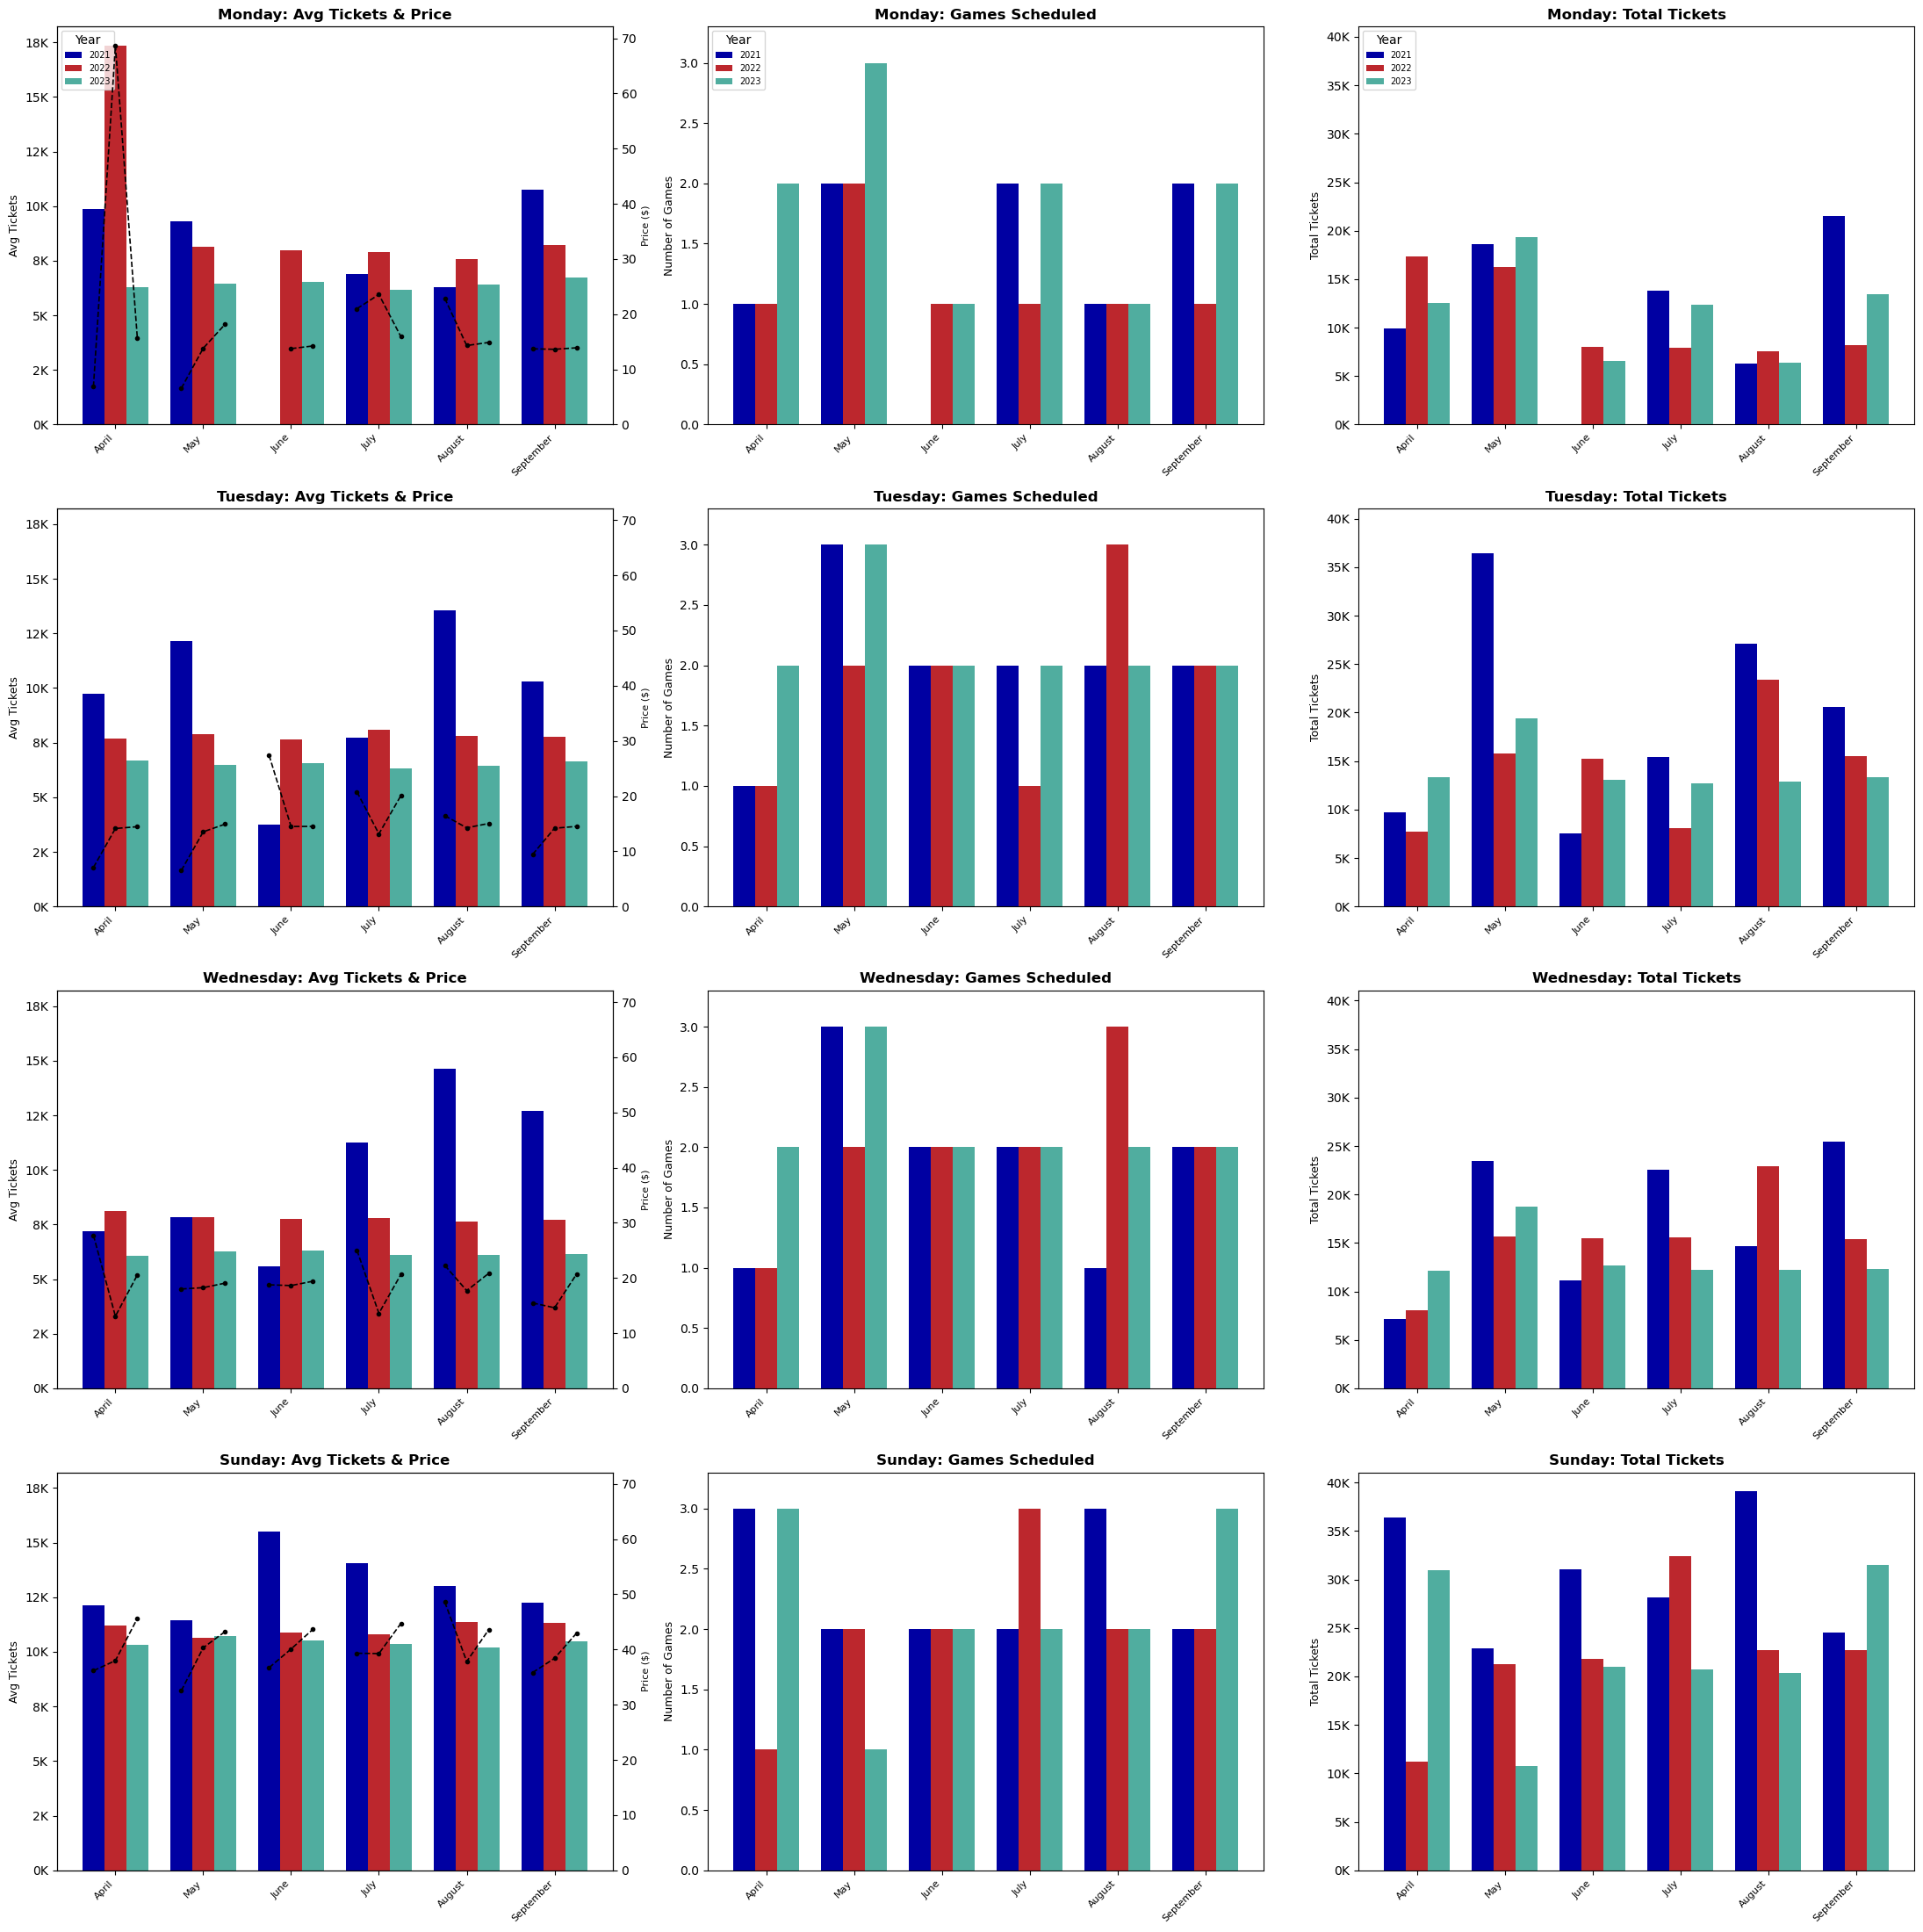

In [5]:
target_days = ['Monday', 'Tuesday', 'Wednesday', 'Sunday']

# First pass: find shared max values across all 4 days for each metric
max_tickets = 0
max_price = 0
max_games = 0
max_total = 0
for day in target_days:
    day_data = full[full['Day of Week'] == day]
    t_pivot = day_data.groupby(['Year', 'Month'])['Single Game Tickets (#)'].mean().unstack().reindex(columns=MONTH_ORDER)
    p_pivot = day_data.groupby(['Year', 'Month'])['Single Game Avg Price ($)'].mean().unstack().reindex(columns=MONTH_ORDER)
    g_pivot = day_data.groupby(['Year', 'Month']).size().unstack().reindex(columns=MONTH_ORDER)
    tot_pivot = day_data.groupby(['Year', 'Month'])['Single Game Tickets (#)'].sum().unstack().reindex(columns=MONTH_ORDER)
    max_tickets = max(max_tickets, t_pivot.max().max())
    max_price = max(max_price, p_pivot.max().max())
    max_games = max(max_games, g_pivot.max().max())
    max_total = max(max_total, tot_pivot.max().max())

fig, axes = plt.subplots(4, 3, figsize=(FIGSIZE[0], FIGSIZE[1]*2.6))

for row, day in enumerate(target_days):
    day_data = full[full['Day of Week'] == day]

    ticket_pivot = day_data.groupby(['Year', 'Month'])['Single Game Tickets (#)'].mean().unstack().reindex(columns=MONTH_ORDER)
    price_pivot = day_data.groupby(['Year', 'Month'])['Single Game Avg Price ($)'].mean().unstack().reindex(columns=MONTH_ORDER)
    game_counts = day_data.groupby(['Year', 'Month']).size().unstack().reindex(columns=MONTH_ORDER)
    total_pivot = day_data.groupby(['Year', 'Month'])['Single Game Tickets (#)'].sum().unstack().reindex(columns=MONTH_ORDER)

    x = range(len(MONTH_ORDER))

    # LEFT: Avg tickets & price
    ax = axes[row, 0]
    for i, (year, color) in enumerate(YEAR_COLORS.items()):
        vals = ticket_pivot.loc[year].fillna(0) if year in ticket_pivot.index else pd.Series(0, index=MONTH_ORDER)
        ax.bar([xi + i * BAR_WIDTH for xi in x], vals, width=BAR_WIDTH, color=color, label=str(year))
    ax.set_title(f'{day}: Avg Tickets & Price', fontsize=12, fontweight='bold')
    ax.set_xticks([xi + BAR_WIDTH for xi in x])
    ax.set_xticklabels(MONTH_ORDER, rotation=45, ha='right', fontsize=8)
    ax.set_ylabel('Avg Tickets', fontsize=9)
    ax.set_ylim(0, max_tickets * 1.05)
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    if row == 0:
        ax.legend(title='Year', loc='upper left', fontsize=7)

    ax_price = ax.twinx()
    for xi in x:
        x_points = [xi + i * BAR_WIDTH for i in range(len(YEARS))]
        y_points = [price_pivot.loc[year].iloc[xi] if year in price_pivot.index else None for year in YEARS]
        ax_price.plot(x_points, y_points, color='black', marker='o', linewidth=1.2, markersize=3, linestyle='dashed')
    ax_price.set_ylabel('Price ($)', fontsize=8)
    ax_price.set_ylim(0, max_price * 1.05)

    # MIDDLE: Games scheduled
    ax_games = axes[row, 1]
    for i, (year, color) in enumerate(YEAR_COLORS.items()):
        vals = game_counts.loc[year].fillna(0) if year in game_counts.index else pd.Series(0, index=MONTH_ORDER)
        ax_games.bar([xi + i * BAR_WIDTH for xi in x], vals, width=BAR_WIDTH, color=color, label=str(year))
    ax_games.set_title(f'{day}: Games Scheduled', fontsize=12, fontweight='bold')
    ax_games.set_xticks([xi + BAR_WIDTH for xi in x])
    ax_games.set_xticklabels(MONTH_ORDER, rotation=45, ha='right', fontsize=8)
    ax_games.set_ylabel('Number of Games', fontsize=9)
    ax_games.set_ylim(0, max_games * 1.1)
    if row == 0:
        ax_games.legend(title='Year', loc='upper left', fontsize=7)

    # RIGHT: Total tickets
    ax_total = axes[row, 2]
    for i, (year, color) in enumerate(YEAR_COLORS.items()):
        vals = total_pivot.loc[year].fillna(0) if year in total_pivot.index else pd.Series(0, index=MONTH_ORDER)
        ax_total.bar([xi + i * BAR_WIDTH for xi in x], vals, width=BAR_WIDTH, color=color, label=str(year))
    ax_total.set_title(f'{day}: Total Tickets', fontsize=12, fontweight='bold')
    ax_total.set_xticks([xi + BAR_WIDTH for xi in x])
    ax_total.set_xticklabels(MONTH_ORDER, rotation=45, ha='right', fontsize=8)
    ax_total.set_ylabel('Total Tickets', fontsize=9)
    ax_total.set_ylim(0, max_total * 1.05)
    ax_total.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
    if row == 0:
        ax_total.legend(title='Year', loc='upper left', fontsize=7)

plt.tight_layout()
plt.show()

**Key Findings:**
- **Seasonality has essentially disappeared for these days by 2023.**  The difference between month-to-month attendance shrank from 2021 levels across all four days (Tuesday's spread went from ~10k tickets to <1k. Whatever drove real seasonal peaks in 2021 no longer exists
- Attendance is down broadly across all four days, not concentrated in a specific stretch - Monday ~25%, Tuesday ~30%, Wednesday ~40%, Sunday ~20%.
- Sunday remains the biggest area of concern because historic volumes are higher

# Additional dives

In [6]:
target_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Sunday']

print("=== Q1: Games scheduled on target days vs. rest of week, by year ===")
target_games = full[full['Day of Week'].isin(target_days)].groupby('Year').size()
other_games = full[~full['Day of Week'].isin(target_days)].groupby('Year').size()
print(f"Target days (Mon/Tue/Wed/Thu/Sun): {target_games.to_dict()}")
print(f"Other days (Fri/Sat): {other_games.to_dict()}")

=== Q1: Games scheduled on target days vs. rest of week, by year ===
Target days (Mon/Tue/Wed/Thu/Sun): {2021: 53, 2022: 55, 2023: 55}
Other days (Fri/Sat): {2021: 28, 2022: 26, 2023: 26}


In [7]:
target_days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Sunday']

# ============================================================
# Q2: Is the decline broad, or driven by outliers?
# ============================================================
print("=== Q2: Distribution of Single Game tickets, target days, 2021 vs 2023 ===")
for year in [2021, 2023]:
    vals = full[(full['Day of Week'].isin(target_days)) & (full['Year']==year)]['Single Game Tickets (#)']
    print(f"{year}: mean={vals.mean():.0f}, median={vals.median():.0f}, std={vals.std():.0f}, min={vals.min():.0f}, max={vals.max():.0f}")

# ============================================================
# Q3: Target days vs overall Single Game decline rate
# ============================================================
print("\n=== Q3: % decline - target days vs overall Single Game ===")
target_pct = (full[(full['Day of Week'].isin(target_days)) & (full['Year']==2023)]['Single Game Tickets (#)'].mean() -
              full[(full['Day of Week'].isin(target_days)) & (full['Year']==2021)]['Single Game Tickets (#)'].mean()) / \
              full[(full['Day of Week'].isin(target_days)) & (full['Year']==2021)]['Single Game Tickets (#)'].mean() * 100
overall_pct = (full[full['Year']==2023]['Single Game Tickets (#)'].mean() - full[full['Year']==2021]['Single Game Tickets (#)'].mean()) / \
               full[full['Year']==2021]['Single Game Tickets (#)'].mean() * 100
print(f"Target days: {target_pct:.1f}%")
print(f"Overall Single Game (all days): {overall_pct:.1f}%")

# ============================================================
# Q4: Uniform across target days, or one bad day driving it?
# ============================================================
print("\n=== Q4: % decline by individual target day ===")
for day in target_days:
    vals = full[full['Day of Week']==day].groupby('Year')['Single Game Tickets (#)'].mean()
    pct = (vals[2023]-vals[2021])/vals[2021]*100
    print(f"{day}: {pct:.1f}%")

# ============================================================
# Q5: No-show rate - purchase problem, or also engagement problem?
# ============================================================
print("\n=== Q5: No-show rate, target days vs other days, by year ===")
target_ns = full[full['Day of Week'].isin(target_days)].groupby('Year')['No-Show Rate'].mean()*100
other_ns = full[~full['Day of Week'].isin(target_days)].groupby('Year')['No-Show Rate'].mean()*100
print(f"Target days: {target_ns.round(1).to_dict()}")
print(f"Other days (Fri/Sat): {other_ns.round(1).to_dict()}")

# ============================================================
# Q6: Is this Single-Game-specific, or do other ticket types also struggle?
# ============================================================
print("\n=== Q6: % decline by segment, target days only ===")
segments = {'Full Season':'Full Season Tickets (#)', 'Partial Season':'Partial Season Tickets (#)',
            'Group':'Group Tickets (#)', 'Single Game':'Single Game Tickets (#)'}
for name, col in segments.items():
    vals = full[full['Day of Week'].isin(target_days)].groupby('Year')[col].mean()
    pct = (vals[2023]-vals[2021])/vals[2021]*100
    print(f"{name}: {pct:.1f}%")

=== Q2: Distribution of Single Game tickets, target days, 2021 vs 2023 ===
2021: mean=10273, median=10122, std=3632, min=2854, max=18133
2023: mean=7514, median=6570, std=2184, min=5930, max=17020

=== Q3: % decline - target days vs overall Single Game ===
Target days: -26.9%
Overall Single Game (all days): -19.0%

=== Q4: % decline by individual target day ===
Monday: -26.7%
Tuesday: -33.0%
Wednesday: -34.9%
Thursday: -5.1%
Sunday: -19.9%

=== Q5: No-show rate, target days vs other days, by year ===
Target days: {2021: 16.4, 2022: 16.9, 2023: 17.3}
Other days (Fri/Sat): {2021: 15.8, 2022: 15.5, 2023: 15.5}

=== Q6: % decline by segment, target days only ===
Full Season: -6.8%
Partial Season: 4.8%
Group: -9.2%
Single Game: -26.9%


## Single Game: Final Thoughts
We set out to answer questions about the Single Game decline on Monday/Tuesday/Wednesday/Sunday, and each one closes out cleanly:

- **It's broad, not outlier-driven.** The 2021-2023 drop shows up in both the mean and median, and the spread across games actually shrank. This is a consistent, portfolio-wide shift, not a few bad dates dragging down an average
- **These days are declining meaningfully faster than Single Game overall** (-26.9% vs. -19.0%), confirming this is a real, distinct problem, not just "the whole season is down and these days happen to have more games"
- **It's not uniform across the four days** - Wednesday (-34.9%) and Tuesday (-33.0%) are the worst hit, Thursday is barely moving (-5.1%), and Monday/Sunday sit in between
- **No-shows are compounding the problem** - rising on these target days (16.4% -> 17.3%) while staying flat on Friday/Saturday (15.8% -> 15.5%)
- **This is specifically a Single Game (casual, one-off buyer) problem, not a "these days are broken" problem.** On these exact same days, Full Season declined only modestly (-6.8%), Group declined less (-9.2%), and Partial Season actually grew (+4.8%). And earlier in this analysis, we confirmed price isn't the driver either, as Partial Season charges MORE than Single Game on these same nights and still grows

**What this means:** the days themselves aren't the problem, and price isn't the problem. Committed, multi-game buyers are thriving on the same games where casual, single-ticket buyers are disappearing. That points to a shift in behavior specific to the casual fan, not something fixable with a pricing lever. This dataset can't tell us the root cause, but it does tell us clearly that **the fix isn't a price change, it's a different kind of engagement**. That may mean converting these lapsed casual buyers into committed, bundled fans through a dedicated product